# Stable results for the measurement-error slides

This notebook generates the fixed Monte Carlo results and figures used in `11_measurement_error.pdf`. The shorter `11_simulation_examples.ipynb` is intended for live experiments.


In [1]:
# Import libraries and locate the figure folder.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

output_dir = Path.cwd() if Path.cwd().name == 'Eksempler' else Path.cwd() / 'Eksempler'
output_dir.mkdir(exist_ok=True)


## 1. Classical measurement error

The true model is $y=1+2x^*+u$, but OLS uses $x=x^*+e$. We simulate 1,000 samples with $n=100$.


In [2]:
# Simulate the slope estimator for a chosen measurement-error variance.
def measurement_error_mc(var_e, S=1000, n=100, seed=117):
    rng = np.random.default_rng(seed)
    slopes = np.empty(S)
    for s in range(S):
        x_star = rng.normal(2, 1, n)
        u = rng.normal(0, 1, n)
        e = rng.normal(0, np.sqrt(var_e), n)
        x = x_star + e
        y = 1 + 2 * x_star + u
        X = np.column_stack((np.ones(n), x))
        slopes[s] = np.linalg.lstsq(X, y, rcond=None)[0][1]
    return slopes


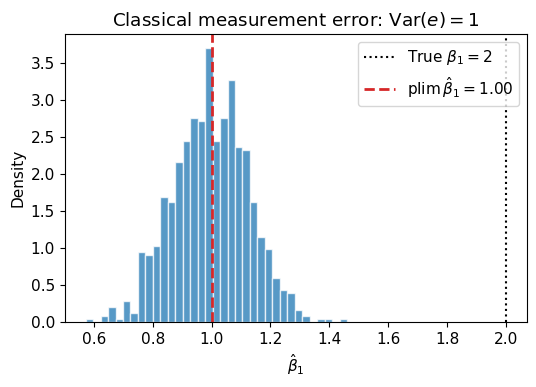

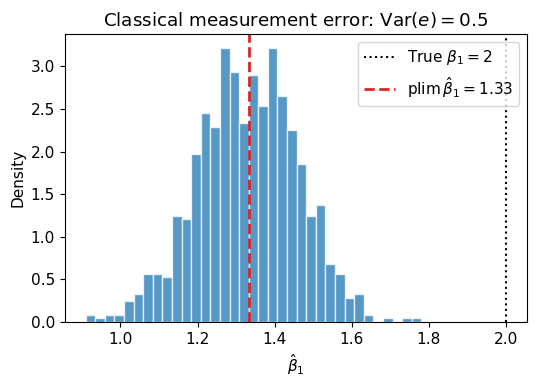

In [3]:
# Generate the two histograms used in the slides.
for var_e, filename in [(1.0, 'Målefejl_hist e1 .pdf'), (0.5, 'Målefejl_hist e.5 .pdf')]:
    slopes = measurement_error_mc(var_e)
    probability_limit = 2 / (1 + var_e)
    with plt.rc_context({'font.size': 11}):
        fig, ax = plt.subplots(figsize=(5.5, 4))
        ax.hist(slopes, bins=35, density=True, color='tab:blue', alpha=0.75, edgecolor='white')
        ax.axvline(2, color='black', linestyle=':', linewidth=1.5, label=r'True $\beta_1=2$')
        ax.axvline(probability_limit, color='tab:red', linestyle='--', linewidth=2,
                   label=rf'$\operatorname{{plim}}\hat\beta_1={probability_limit:.2f}$')
        ax.set(xlabel=r'$\hat\beta_1$', ylabel='Density',
               title=rf'Classical measurement error: $\operatorname{{Var}}(e)={var_e:g}$')
        ax.legend()
        fig.tight_layout()
        fig.savefig(output_dir / filename)
        plt.show()


## 2. Sample selection: fixed Monte Carlo results

The outcome and selection equations are

$$
y_i=1+x_i+u_i,
\qquad
s_i=1(\delta_1x_i+v_i>0),
$$

where $v_i=\rho u_i+\sqrt{1-\rho^2}e_i$ and $x_i,u_i,e_i$ are independent standard normal variables.


In [4]:
# Simulate all four selection mechanisms using the same Monte Carlo draws.
scenarios = [
    ('Random', 0, 0),
    ('Only x', 1, 0),
    ('Only u', 0, 0.7),
    ('x and u', 1, 0.7)
]

rng = np.random.default_rng(117)
estimates = {name: [] for name, _, _ in scenarios}
selection_rates = {name: [] for name, _, _ in scenarios}

for repetition in range(1000):
    x = rng.normal(0, 1, 1000)
    u = rng.normal(0, 1, 1000)
    e = rng.normal(0, 1, 1000)
    y = 1 + x + u
    for name, delta1, rho in scenarios:
        v = rho * u + np.sqrt(1 - rho**2) * e
        s = delta1 * x + v > 0
        X_selected = np.column_stack((np.ones(s.sum()), x[s]))
        estimates[name].append(np.linalg.lstsq(X_selected, y[s], rcond=None)[0])
        selection_rates[name].append(s.mean())

# Display the fixed numbers reported in the slides.
selection_results = pd.DataFrame([
    {'Selection': name, 'delta1': delta1, 'rho': rho,
     'Mean intercept': np.mean(estimates[name], axis=0)[0],
     'Mean slope': np.mean(estimates[name], axis=0)[1],
     'Selection rate': np.mean(selection_rates[name])}
    for name, delta1, rho in scenarios
])
display(selection_results.round(3))


,Selection,delta1,rho,Mean intercept,Mean slope,Selection rate
0,Random,0,0.0,1.000,1.001,0.500
1,Only x,1,0.0,1.001,1.001,0.501
2,Only u,0,0.7,1.559,0.999,0.500
3,x and u,1,0.7,1.579,0.674,0.500


## 3. Graphical illustrations of selection on $x$ and $y$

These figures are generated separately so the slide figures remain stable when live parameters are changed in the teaching notebook.


In [5]:
# Generate one common data set for all three selection figures.
rng = np.random.default_rng(117)
selection_data = pd.DataFrame({'x': rng.uniform(0, 20, 500)})
selection_data['y'] = 10 + selection_data['x'] + rng.normal(0, 5, len(selection_data))


In [6]:
# Plot a selected sample together with its OLS regression line.
def save_selection_plot(sample, color, filename, title):
    X = np.column_stack((np.ones(len(sample)), sample['x']))
    b0, b1 = np.linalg.lstsq(X, sample['y'], rcond=None)[0]
    x_grid = np.linspace(0, 20, 100)
    with plt.rc_context({'font.size': 11}):
        fig, ax = plt.subplots(figsize=(5.5, 4))
        ax.scatter(selection_data['x'], selection_data['y'], s=10, alpha=0.12, color='grey')
        ax.scatter(sample['x'], sample['y'], s=12, alpha=0.40, color=color)
        ax.plot(x_grid, b0 + b1 * x_grid, color=color, linewidth=2,
                label=rf'$\hat\beta_1={b1:.2f}$')
        ax.set(xlabel='$x$', ylabel='$y$', title=title, xlim=(0, 20))
        ax.legend()
        fig.tight_layout()
        fig.savefig(output_dir / filename)
        plt.show()


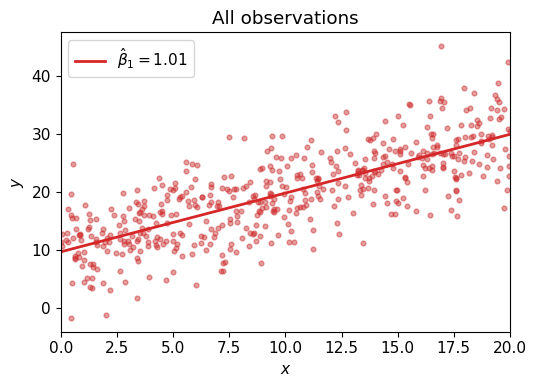

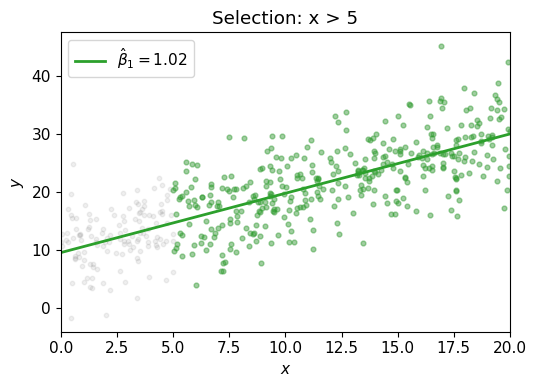

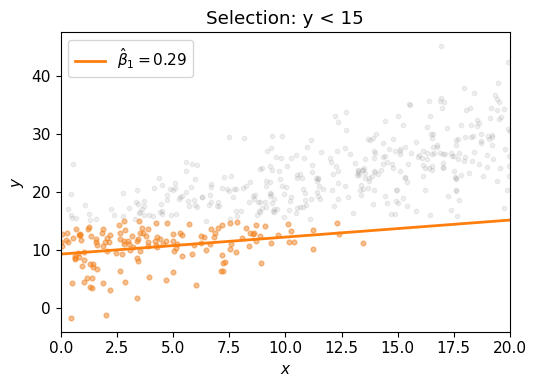

In [7]:
# Save the full sample, selection on x, and selection on y.
save_selection_plot(selection_data, 'tab:red', 'Dataudvælgelse Alle.pdf', 'All observations')
save_selection_plot(selection_data[selection_data['x'] > 5], 'tab:green',
                    'Dataudvælgelse x5.pdf', 'Selection: x > 5')
save_selection_plot(selection_data[selection_data['y'] < 15], 'tab:orange',
                    'Dataudvælgelse y15.pdf', 'Selection: y < 15')
